# 9.2 使用pandas和seaborn绘图

## 9.2.1 线状图

<Axes: >

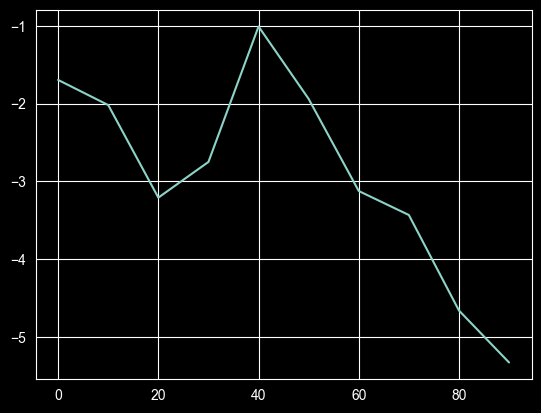

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# series和dataframe都有plot属性 默认情况下生成现状图
s = pd.Series(np.random.randn(10).cumsum(),index=np.arange(0,100,10))
s.plot()

#### Series.plot参数

In [ ]:
# use_index=False 禁用将索引设置为X轴
# grid=True 显示网格线
# ax 绘图所用的matplotlib子图对象 默认当前

<Axes: >

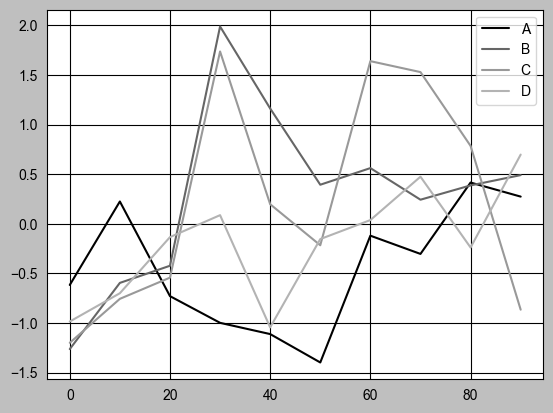

In [2]:
df = pd.DataFrame(np.random.randn(10,4).cumsum(axis=0), columns=['A','B','C','D'], index=np.arange(0,100,10))
plt.style.use('grayscale')  # 配色方案调成灰度
df.plot()

#### DataFrame.plot参数

In [ ]:
# subplots 将DataFrame的列绘入不同子图
# layouts 用于子图布局的二元组
# sharex 若subplots=True 共享x轴
# sharey 同上
# legend 添加子图图例 默认True

## 9.2.2 柱状图

<Axes: >

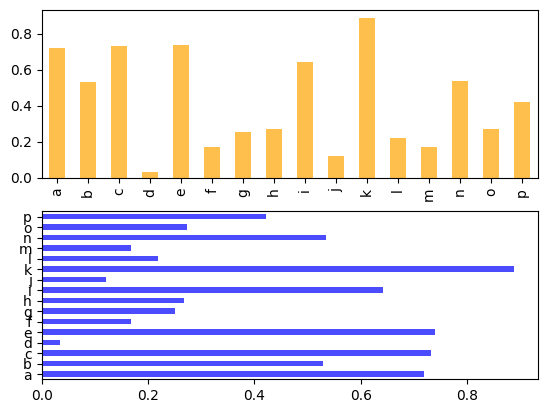

In [9]:
# bar水平柱状图 barh垂直柱状图
plt.style.use('default')
fig,axes = plt.subplots(2,1)
data = pd.Series(np.random.uniform(size=16), index=list('abcdefghijklmnop'))
data.plot.bar(ax=axes[0], color='orange', alpha=0.7)
data.plot.barh(ax=axes[1], color='blue', alpha=0.7)

In [10]:
df = pd.DataFrame(np.random.uniform(size=(6,4)),index=['one','two','three','four','five','six'],columns=pd.Index(['A','B','C','D'],name='Genus'))
df

Genus,A,B,C,D
one,0.746894,0.373402,0.912596,0.379496
two,0.495946,0.105504,0.293845,0.470273
three,0.134708,0.299402,0.211273,0.431318
four,0.614831,0.135242,0.361633,0.606939
five,0.262049,0.166910,0.892585,0.520879
six,0.358642,0.602178,0.492554,0.026569


<Axes: >

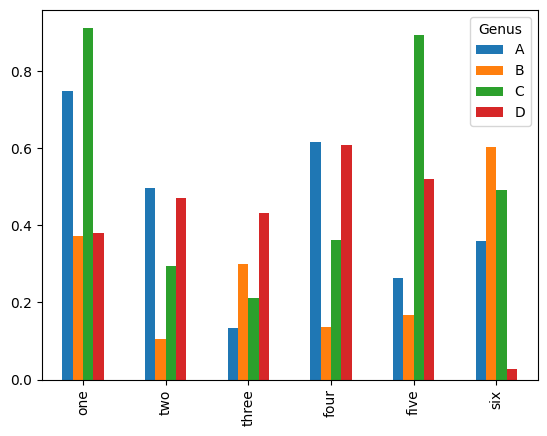

In [11]:
df.plot.bar()

<Axes: >

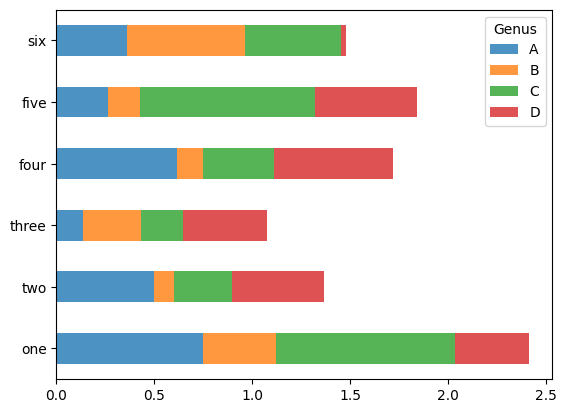

In [12]:
df.plot.barh(stacked=True, alpha=0.8)  # 堆积

In [ ]:
# s.value_counts().plot.bar() 很有效的可视化频率

In [13]:
tips = pd.read_csv('../examples/tips.csv')
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [14]:
party_counts = pd.crosstab(tips['day'],tips['size'])  # 计算出简单的频率表
party_counts = party_counts.reindex(['Thur','Fri','Sat','Sun'])
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


In [16]:
party_counts = party_counts.loc[:,2:5]
# 正态化以使各行和为1
party_pcts = party_counts.div(party_counts.sum(axis=1),axis=0)
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


<Axes: xlabel='day'>

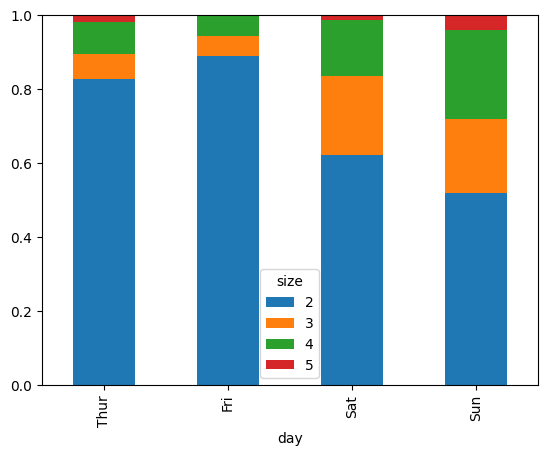

In [18]:
party_pcts.plot.bar(stacked=True)

In [19]:
import seaborn as sns
tips['tip_pct'] = tips['tip']/(tips['total_bill']-tips['tip'])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

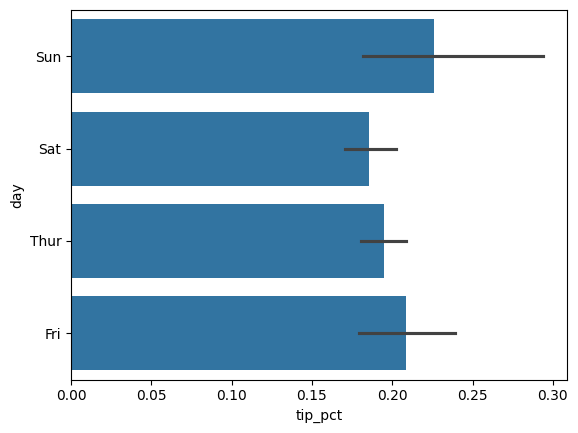

In [20]:
sns.barplot(x='tip_pct',y='day',data=tips,orient='h')

## 9.2.3 直方图和密度图

<Axes: ylabel='Frequency'>

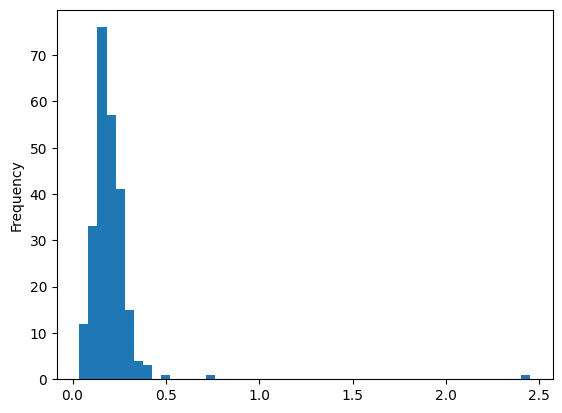

In [21]:
tips['tip_pct'].plot.hist(bins=50)

<Axes: ylabel='Density'>

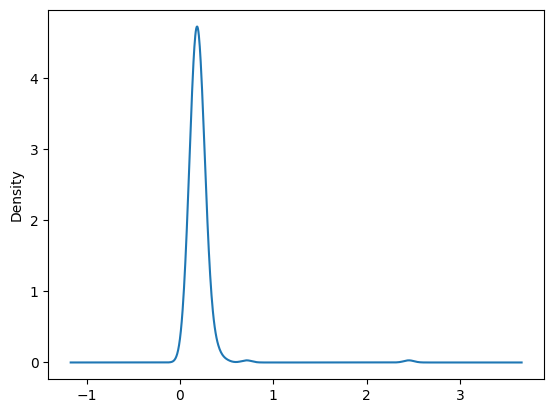

In [23]:
# 常规混合正态分布 KDE
tips['tip_pct'].plot.density()

<Axes: ylabel='Count'>

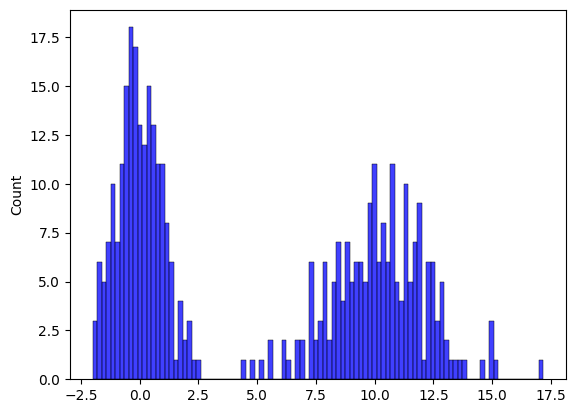

In [24]:
# 使用seaborn的histplot方法绘制更简单
comp1 = np.random.randn(200)
comp2 = 10+ 2*np.random.randn(200)
values = pd.Series(np.concatenate([comp1,comp2]))
sns.histplot(values,bins=100,color='blue')

## 9.2.4 散点图或点图

In [28]:
macro = pd.read_csv('../examples/macrodata.csv')
data = macro.loc[:,['cpi','m1','tbilrate','unemp']]
trans_data = np.log(data).diff().dropna()
trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


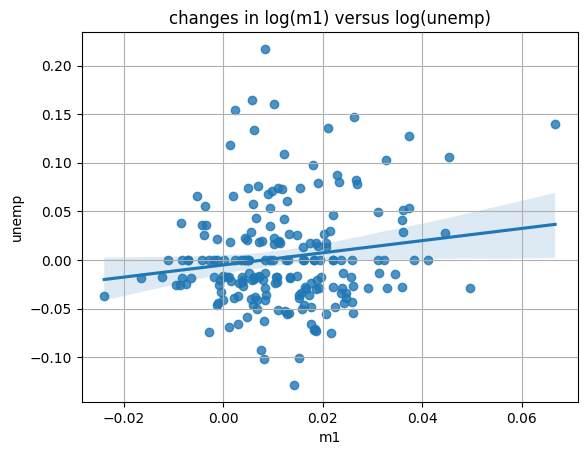

In [33]:
# seaborn.regplot 生成散点图并添加一条线性回归拟合的直线
ax = sns.regplot(x='m1',y='unemp',data=trans_data)
ax.set_title('changes in log(m1) versus log(unemp)')
ax.grid(True)

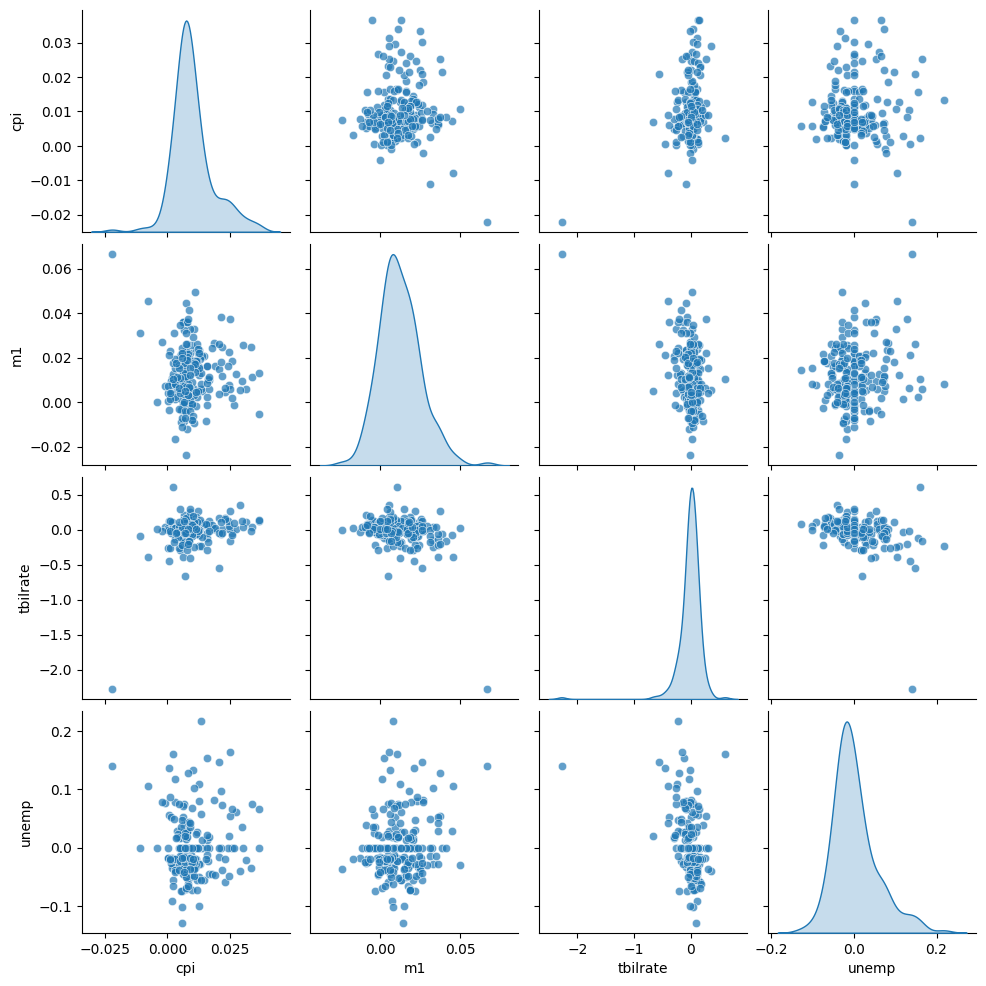

In [34]:
sns.pairplot(trans_data,diag_kind='kde',plot_kws={'alpha':0.7})

## 9.2.5 分面网格和分类数据

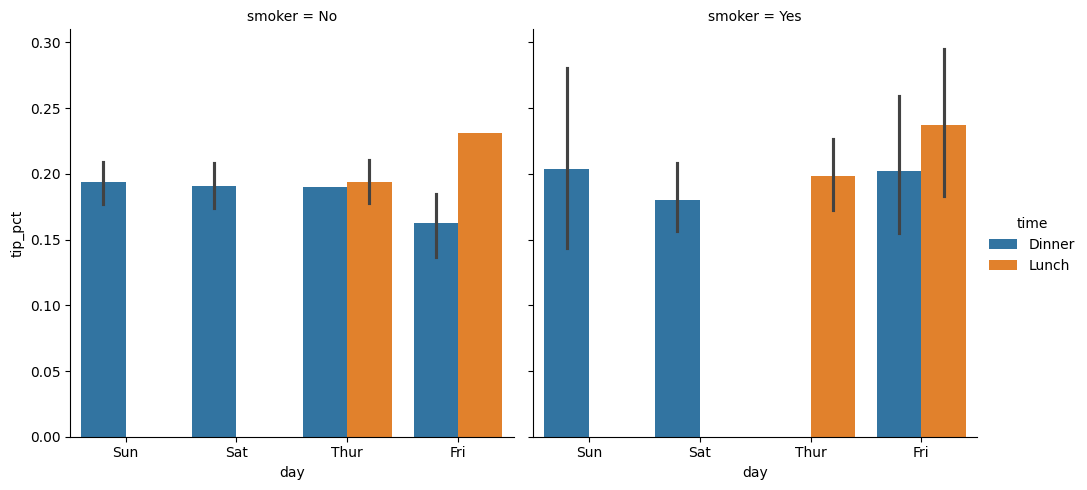

In [35]:
sns.catplot(x='day',y='tip_pct',hue='time',col='smoker',kind='bar',data=tips[tips.tip_pct<1])

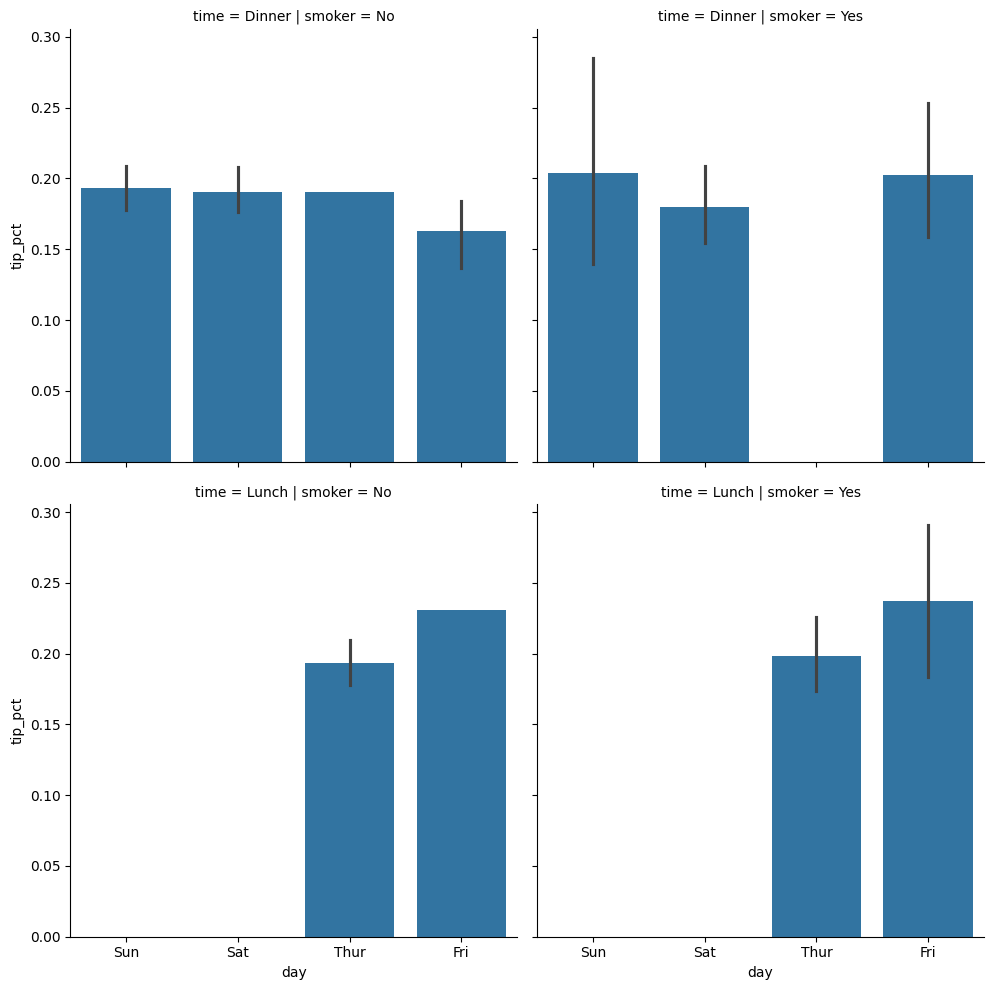

In [36]:
sns.catplot(x='day',y='tip_pct',row='time',col='smoker',kind='bar',data=tips[tips.tip_pct<1])

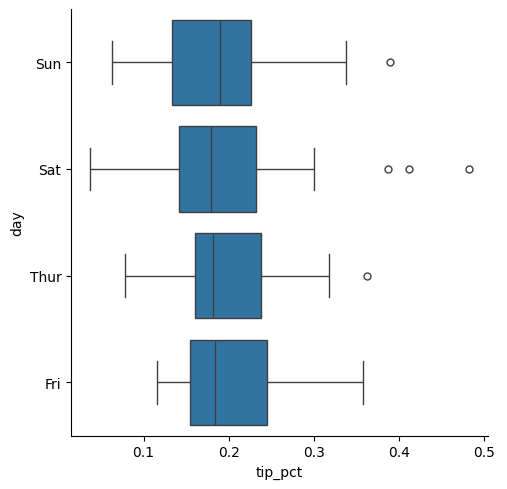

In [37]:
sns.catplot(x='tip_pct',y='day',kind='box',data=tips[tips.tip_pct<0.5])

# End